In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys, os
sys.path.append("./morphomnist") 

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from prepare_data import prepare_flow_data, unflatten, inverse_logit

In [14]:

SIZE = 8
data = prepare_flow_data("morphomnist/data/", size=SIZE, seed=0)

In [15]:
Z = np.asarray(data["Z"])        # shape (n, 11): [thickness, digit_onehot(10)]
digit_onehot = Z[:, 1:]          # (n, 10)
labels = np.argmax(digit_onehot, axis=1)
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))
# digit-0 count:
print("digit 0 count:", (labels == 0).sum())

{np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}
digit 0 count: 5923


In [16]:
# Start from the existing prepared Morphomnist data
# `data["Z"][:,1]` is the digit label, so zeros are digit 0
zero_idx = np.where(Z[:, 1] == 1)[0]   # column 1 equals 1 means digit == 0


In [17]:
data["Z"].shape

(60000, 11)

In [18]:
zero_idx.shape

(5923,)

In [21]:
#N=1000 # If you want exactly N zeros
#sel = rng.choice(zero_idx, N, replace=False)  # choose a smaller toy subset

Y0 = np.asarray(data["Y0"])[zero_idx]          # untreated images in flow space
Z0 = np.asarray(data["Z"])[zero_idx]           # covariate/digit info
seed = 123
rng = np.random.default_rng(seed)

In [36]:
# Random treatment assignment for a clean toy experiment
X = (rng.uniform(size=len(Y0)) < 0.5).astype(np.float64)[:, None]

# Define a fixed central white circle effect in pixel space
size = 8
xx, yy = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
radius = 2
circle = ((xx - (size - 1) / 2) ** 2 + (yy - (size - 1) / 2) ** 2 <= radius**2).astype(np.float64)

# Choose the effect magnitude in logit space
circle_flat = circle.reshape(1, -1)         # (1, 64)
base_shift = 1.0
ITE = base_shift * circle_flat              # (1,64) -> will broadcast to (n,64)
Y1 = Y0 + ITE                               # broadcasts correctly
Y = np.where(X == 1, Y1, Y0)

toy_data = {
    "Y": jnp.asarray(Y),
    "X": jnp.asarray(X),
    "Z": jnp.asarray(Z0)[:,0],
    "Y0": jnp.asarray(Y0),
    "Y1": jnp.asarray(Y1),
    "ITE": jnp.asarray(ITE),
    "ATE": jnp.asarray(ITE.mean(axis=0)),
}

max |ITE|: 1.0
nonzero fraction: 0.1875
per-unit nonzero pixels: [12]


Text(0.5, 1.0, 'mean |ITE| per pixel')

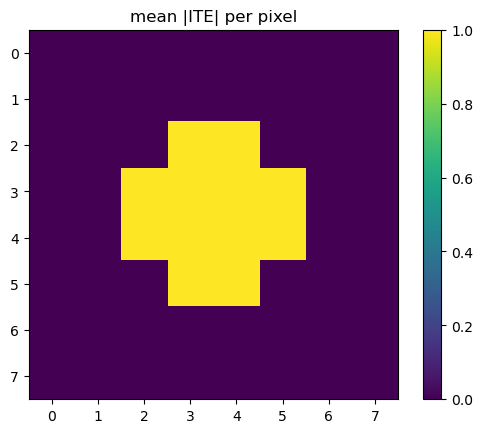

In [37]:
ITE = np.asarray(toy_data["ITE"])
print("max |ITE|:", np.abs(ITE).max())
print("nonzero fraction:", (ITE != 0).mean())          # expect roughly the ink fraction, ~0.15–0.3
print("per-unit nonzero pixels:", (ITE != 0).sum(axis=1)[:10])
plt.imshow(np.abs(ITE).mean(axis=0).reshape(SIZE, SIZE)); plt.colorbar()
plt.title("mean |ITE| per pixel")  # should light up where digits are

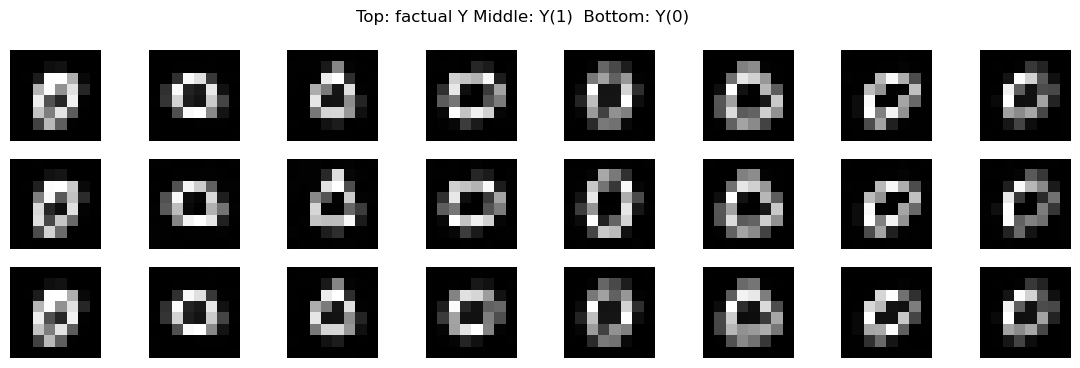

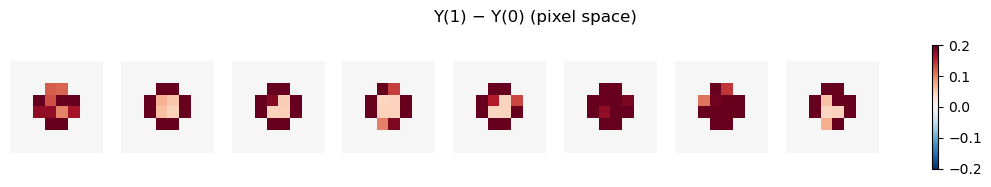

In [38]:
fig, axes = plt.subplots(3, 8, figsize=(14, 4))
imgs = inverse_logit(np.asarray(toy_data["Y"][:8]))          # back to [0,1]
for i, ax in enumerate(axes[0]):
    ax.imshow(unflatten(imgs[i], SIZE)[0], cmap="gray"); ax.axis("off")
axes[0, 0].set_ylabel("factual", rotation=0)

# untreated potential outcome for the same units
imgs0 = inverse_logit(np.asarray(toy_data["Y0"][:8]))
for i, ax in enumerate(axes[1]):
    ax.imshow(unflatten(imgs0[i], SIZE)[0], cmap="gray"); ax.axis("off")

# treated potential outcome for the same units
imgs1 = inverse_logit(np.asarray(toy_data["Y1"][:8]))
for i, ax in enumerate(axes[2]):
    ax.imshow(unflatten(imgs1[i], SIZE)[0], cmap="gray"); ax.axis("off")
plt.suptitle("Top: factual Y Middle: Y(1)  Bottom: Y(0)")
plt.show()


T = np.asarray(toy_data["X"]).flatten().astype(bool)
diff = inverse_logit(np.asarray(toy_data["Y1"])) - inverse_logit(np.asarray(toy_data["Y0"]))

idx = np.where(T)[0][:8]
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in zip(idx, axes):
    im = ax.imshow(diff[i].reshape(SIZE, SIZE), cmap="RdBu_r",
                   vmin=-0.2, vmax=0.2)
    ax.axis("off")
plt.suptitle("Y(1) − Y(0) (pixel space)")
plt.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [40]:
np.asarray(toy_data["Z"])

array([ 0.00299724, -0.45106363, -0.5138827 , ..., -0.28759843,
       -0.1749392 , -0.5549794 ], shape=(5923,), dtype=float32)

treated fraction: 0.510


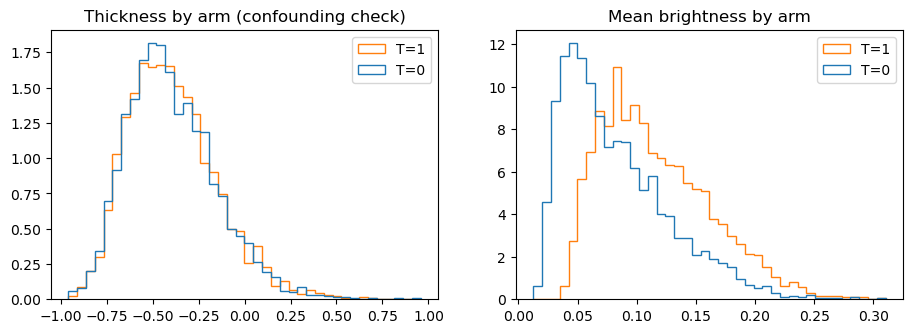

In [41]:
T = np.asarray(toy_data["X"]).flatten()
thickness = np.asarray(toy_data["Z"])
print(f"treated fraction: {T.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist([thickness[T==0], thickness[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[0].legend(); axes[0].set_title("Thickness by arm (confounding check)")

# naive vs adjusted difference in mean brightness
mean_bright = inverse_logit(toy_data["Y"]).mean(axis=1)
axes[1].hist([mean_bright[T==0], mean_bright[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[1].legend(); axes[1].set_title("Mean brightness by arm")
plt.show()

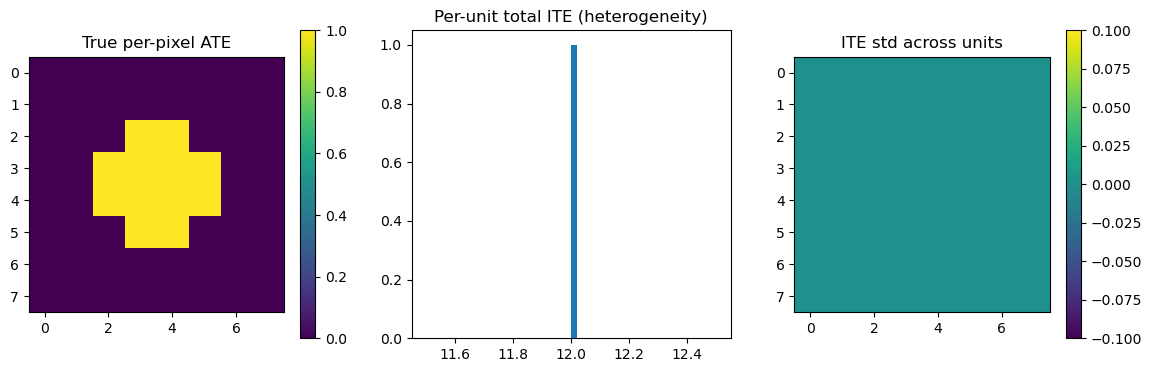

In [42]:
ATE = np.asarray(toy_data["ATE"])           # (K,)
ITE = np.asarray(toy_data["ITE"])           # (n, K)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im = axes[0].imshow(ATE.reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[0])
axes[0].set_title("True per-pixel ATE")

axes[1].hist(ITE.sum(axis=1), bins=50)
axes[1].set_title("Per-unit total ITE (heterogeneity)")

im = axes[2].imshow(ITE.std(axis=0).reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[2])
axes[2].set_title("ITE std across units")
plt.show()

In [43]:
toy_data["Z"].shape


(5923,)

## Frugal flow

In [44]:
import equinox as eqx
import inspect
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import frugal_flows

from frugal_flows.basic_flows import (masked_independent_flow, 
                                        masked_autoregressive_flow_first_uniform, 
                                        masked_autoregressive_flow_masked_cond)
from frugal_flows.bijections import UnivariateNormalCDF
from frugal_flows.causal_flows import (train_frugal_flow, 
                                        train_frugal_flow_location_translation,
                                        train_copula_flow, 
                                        get_independent_quantiles, 
                                        univariate_discrete_cdf,
                                        independent_continuous_marginal_flow)
from frugal_flows.train_quantile_propensity_score import train_quantile_propensity_score

import flowjax
from flowjax.distributions import Transformed, Uniform, _StandardUniform
from flowjax.flows import masked_autoregressive_flow
from flowjax.train import fit_to_data
from flowjax.bijections.utils import Identity
from flowjax.bijections import (
    Affine,
    Invert,
    MaskedAutoregressive,
    RationalQuadraticSpline,
    Stack,
    Tanh,
)
import pandas as pd

SEED = 34


jax.config.update("jax_enable_x64", False)



In [45]:
key = jr.PRNGKey(SEED)

In [46]:
z_cont = toy_data["Z"][:,None]

In [47]:
z_cont.shape

(5923, 1)

In [48]:
key, subkey = jr.split(key)

In [49]:
z_res = get_independent_quantiles(key = subkey,
                                z_cont=z_cont,
                                max_epochs = 70,
                                max_patience=10,
                                return_z_cont_flow = True,
                             )

 43%|████▎     | 30/70 [00:23<00:31,  1.26it/s, train=-0.0333, val=-0.0385 (Max patience reached)]


In [50]:
u_z = np.hstack([z_res['u_z_cont']])
u_z.shape

(5923, 1)

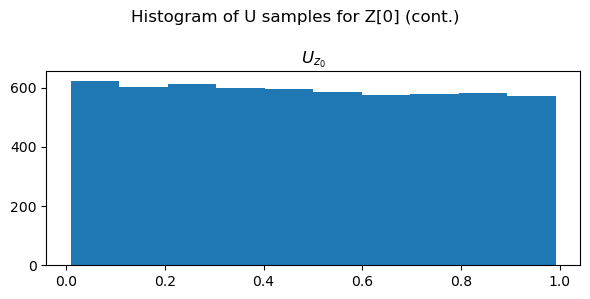

In [51]:
fig, ax = plt.subplots(figsize=(6,3))
fig.suptitle('Histogram of U samples for Z[0] (cont.)')
ax.hist(z_res['u_z_cont'][:,0])
ax.set_title(r'$U_{z_0}$')
plt.tight_layout()
plt.show()

In [52]:
Y = toy_data["Y"]

In [88]:
key, subkey = jr.split(key)
frugal_flow, losses = train_frugal_flow(
    causal_model="location_translation",
    key=subkey,
    y=Y,
    u_z=u_z, 
    learning_rate=1e-2, #5e-3,
    max_epochs=100,
    max_patience=30,
    batch_size=100,
    condition=toy_data["X"],
    causal_model_args={"ate":0.5, "RQS_knots":8, "nn_depth":1, "nn_width":50, "flow_layers":4},
)

100%|██████████| 100/100 [03:31<00:00,  2.11s/it, train=-51.4, val=-51.1]


In [1]:
train = np.array(losses['train'])
val = np.array(losses['val'])
epochs = np.arange(1, len(train) + 1)

plt.figure(figsize=(8,4))
plt.plot(epochs, train, label='train', marker='o', markersize=4)
plt.plot(epochs, val, label='val', marker='o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'np' is not defined

In [2]:
import paramax
loccond_block = frugal_flow.bijection.bijections[5]
tau_hat = jnp.array([float(paramax.unwrap(loccond_block.bijections[k]).ate) for k in range(64)])
print(" tau_hat:", tau_hat)

NameError: name 'frugal_flow' is not defined

In [ ]:
tau_hat.shape
toy_data["ATE"].shape

(64,)

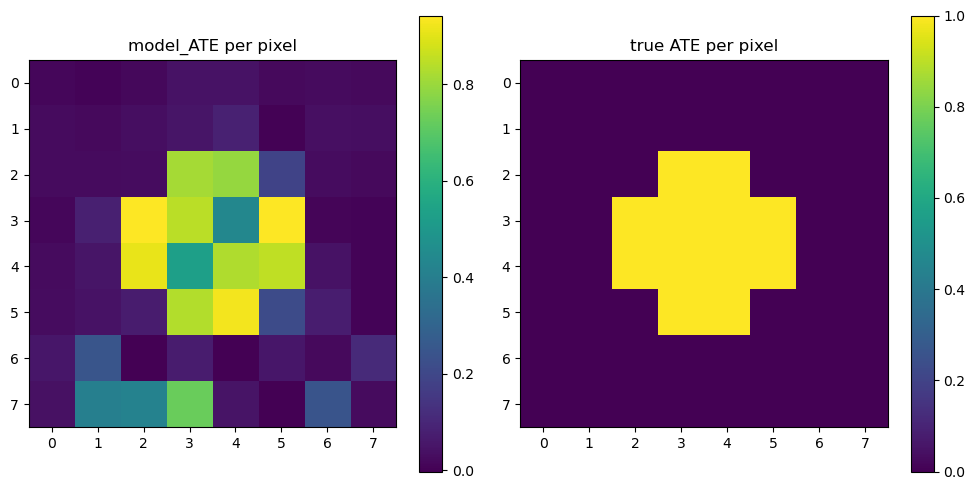

In [87]:
model_ATE = np.asarray(tau_hat)
true_ATE = np.asarray(toy_data["ATE"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
im0 = axes[0].imshow(model_ATE.reshape(SIZE, SIZE)); axes[0].set_title("model_ATE per pixel")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(true_ATE.reshape(SIZE, SIZE)); axes[1].set_title("true ATE per pixel")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

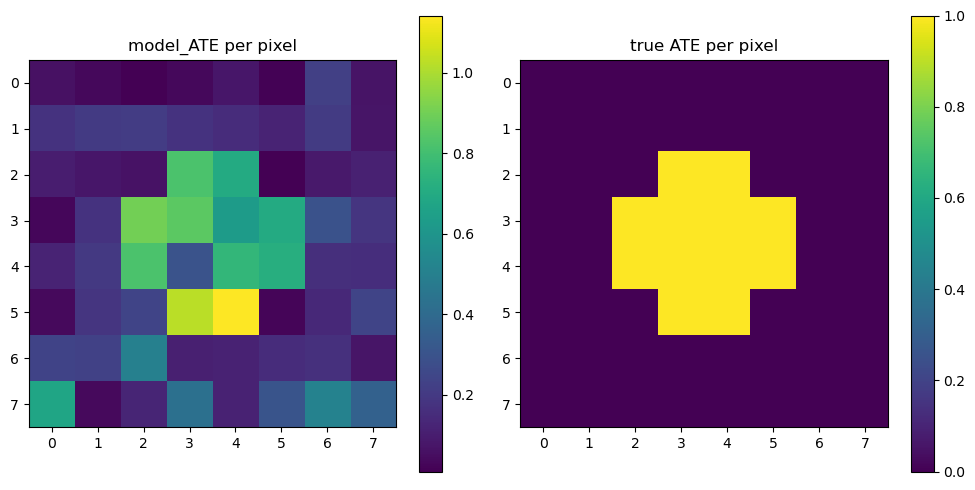

In [78]:
model_ATE = np.asarray(tau_hat)
true_ATE = np.asarray(toy_data["ATE"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
im0 = axes[0].imshow(model_ATE.reshape(SIZE, SIZE)); axes[0].set_title("model_ATE per pixel")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(true_ATE.reshape(SIZE, SIZE)); axes[1].set_title("true ATE per pixel")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()